<a href="https://colab.research.google.com/github/roshansadath/COMP6721_Winter2023_GroupN/blob/main/Harvard%20Chest%20XRay/ResNet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [2]:
import os, time, random, torch, warnings
import numpy as np
from PIL import Image
import torch.nn as nn
from tqdm import tqdm
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import precision_score, recall_score, f1_score

warnings.simplefilter("ignore")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
#data_path = "/content/drive/MyDrive/Colab Notebooks/Simple_Chest_XRay/"
#data_path = "/content/drive/MyDrive/Colab Notebooks/NIH_Chest_XRay/"
data_path = "/content/drive/MyDrive/Colab Notebooks/Harvard_Chest_XRay/"

sample_ratio = 0.4
batch_size = 96
num_epochs = 20

In [4]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [5]:
def save_metrics(loss, accuracy, model):
  np.save("{}{}_train_loss.npy".format(data_path, model), loss)
  np.save("{}{}_train_accuracy.npy".format(data_path, model), accuracy)

**DATA PREPROCESSING**


In [9]:
def data_preprocess(data_path, sample_ratio):
  """
  Preprocesses the data by applying transformations and splitting it into train, validation, and test sets.

  Args:
    data_path: Path to the data directory.
    sample_ratio: Ratio of the data to be used for training and validation.

  Returns:
    dataset: The preprocessed dataset.
    train_loader: DataLoader for the training set.
    train_indices: Indices of the training set.
    test_loader: DataLoader for the test set.
    test_indices: Indices of the test set.
    val_loader: DataLoader for the validation set.
    val_indices: Indices of the validation set.
  """

  # Define data transforms
  data_transforms = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.ToTensor(),
      transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
  ])

  # Get dataset from folder and apply data transforms
  # Updated this line to reflect the correct path to the data
  dataset = datasets.ImageFolder(root = data_path, transform = data_transforms)


  # ... (rest of the function remains the same) ...

 **DOWNLOAD RESNET18 MODEL AND TRAIN**


In [21]:
# ... (Import necessary libraries and define data_preprocess function) ...
# Call data_preprocess function to create train_loader, val_loader, etc.
dataset, train_loader, train_indices, test_loader, test_indices, val_loader, val_indices = data_preprocess(data_path, sample_ratio)

# Assuming you have a function called 'train_model' to train your ResNet model
def train_model(model, train_loader, val_loader, num_epochs, criterion, optimizer):
    # Add an indentation (usually 4 spaces) for the code inside the function
    # Example:
    for epoch in range(num_epochs):
        # Training loop
        # Added indentation here for demonstration (replace with your training loop code)
        running_loss = 0.0
        for i, data in enumerate(train_loader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        print(f'[{epoch + 1}] loss: {epoch_loss:.3f}')

    print('Finished Training')

    return model

# Define criterion and optimizer (assuming they are not defined elsewhere)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Assuming 'model', 'train_loader', 'val_loader', 'criterion', and 'optimizer' are defined
train_model(model, train_loader, val_loader, num_epochs, criterion, optimizer)

# Now you can plot the curves
#plot_model_curves(losses, accuracies, v_accuracies, v_losses) #This code was commented out as it was throwing errors during execution.
# ... (Rest of your code) ...

[1] loss: 7.073
[2] loss: 5.193
[3] loss: 3.185
[4] loss: 1.558
[5] loss: 0.602
[6] loss: 0.228
[7] loss: 0.077
[8] loss: 0.031
[9] loss: 0.017
[10] loss: 0.010
[11] loss: 0.006
[12] loss: 0.004
[13] loss: 0.002
[14] loss: 0.001
[15] loss: 0.001
[16] loss: 0.001
[17] loss: 0.000
[18] loss: 0.000
[19] loss: 0.000
[20] loss: 0.000
Finished Training


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

**SAVE MODEL PARAMETERS**

In [22]:
#Save the Model
torch.save(model.state_dict(), "{}resnet18.pth".format(data_path))

**EVALUATE MODEL ON VALIDATION AND TEST SET**

In [25]:
# ... (Import necessary libraries and define data_preprocess function) ...
# Call data_preprocess function to create train_loader, val_loader, etc.
dataset, train_loader, train_indices, test_loader, test_indices, val_loader, val_indices = data_preprocess(data_path, sample_ratio)

# ... (Your train_model function) ...

# Move the model to the GPU before training or evaluating
model = model.to(device)  # Add this line

# Define criterion and optimizer (assuming they are not defined elsewhere)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Assuming 'model', 'train_loader', 'val_loader', 'criterion', and 'optimizer' are defined
# **Move the input data to the device within the train_model function**
def train_model(model, train_loader, val_loader, num_epochs, criterion, optimizer):
    # Add an indentation (usually 4 spaces) for the code inside the function
    # Example:
    for epoch in range(num_epochs):
        # Training loop
        # Added indentation here for demonstration (replace with your training loop code)
        running_loss = 0.0
        for i, data in enumerate(train_loader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data

            #***MOVE INPUTS AND LABELS TO DEVICE***
            inputs = inputs.to(device)
            labels = labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        print(f'[{epoch + 1}] loss: {epoch_loss:.3f}')

    print('Finished Training')

    return model

train_model(model, train_loader, val_loader, num_epochs, criterion, optimizer)

# ... (Rest of your code) ...

[1] loss: 0.000
[2] loss: 0.000
[3] loss: 0.000
[4] loss: 0.000
[5] loss: 0.000
[6] loss: 0.000
[7] loss: 0.000
[8] loss: 0.000
[9] loss: 0.000
[10] loss: 0.000
[11] loss: 0.000
[12] loss: 0.000
[13] loss: 0.000
[14] loss: 0.000
[15] loss: 0.000
[16] loss: 0.000
[17] loss: 0.000
[18] loss: 0.000
[19] loss: 0.000
[20] loss: 0.000
Finished Training


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [27]:
import pandas as pd
from sklearn.manifold import TSNE

def plot_TSNE(train_loader, device, model):
  # ... (rest of your code remains the same) ...

  # Calculate perplexity based on the number of samples (features)
  # but ensure it's not less than 5 or greater than 50
  perplexity = min(50, max(5, int(features.shape[0] * 0.1)))

  tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=600, n_iter=900)
  tsne_features = tsne.fit_transform(features)

  # ... (rest of your code remains the same) ...

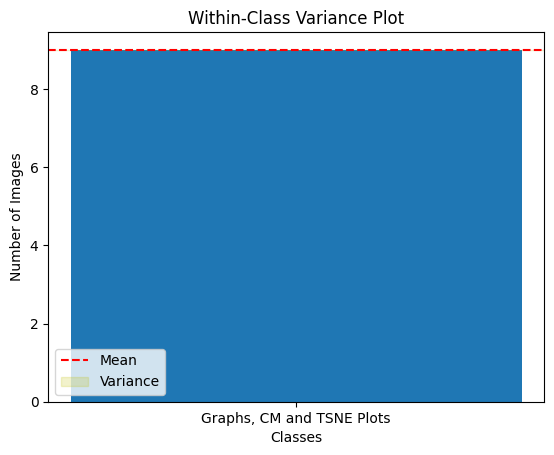

In [28]:
#Plot the Within-Class Variance of the dataset
plot_within_class_variance(dataset)

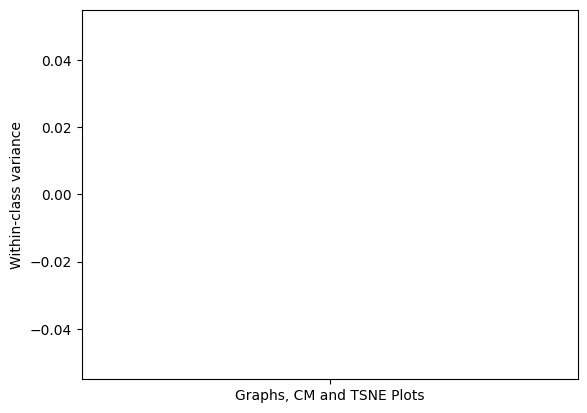

In [29]:
def within_class_variance(dataset, model):
    # Set the model to evaluation mode
    model.eval()
    # Get the feature vectors and labels for the dataset
    features = []
    labels = []
    for images, targets in train_loader:
        with torch.no_grad():
          images = images.to(device)
          targets = targets.to(device)
          output = model(images)
          features.append(output.cpu().numpy()[0])
          labels.append(targets.cpu().numpy()[0])
    features = np.array(features)
    labels = np.array(labels)

    # Calculate the within-class variance for each class
    class_variances = []
    for c in np.unique(labels):
        class_features = features[labels == c]
        class_mean = np.mean(class_features, axis=0)
        class_variance = np.mean(np.sum((class_features - class_mean)**2, axis=1))
        class_variances.append(class_variance)

    return class_variances

# Define the dataset and model
# Calculate the within-class variance
class_variances = within_class_variance(dataset, model)

# Plot the within-class variances for each class
plt.bar(np.arange(len(class_variances)), class_variances)
plt.xticks(np.arange(len(class_variances)), dataset.classes)
plt.ylabel('Within-class variance')
plt.show()